# Calidad de Aire en CDMX usando datos de RAMA

Autor: Thanos Drossos

Clase: Análisis Exploratorio de Datos


## Tarea

1. ESCOGER AL MENOS TRES ESTACIONES DE MONITOREO, QUE REGISTREN O3, CO Y NO2.

Estaciones (claves): BJU, UAX, MER

2. REGISTRAR EL PROMEDIO DIARIO DE CADA CONTAMINANTE POR UN PERIODO CONTINUO DE AL MENOS TRES AÑOS.

Periodo: 2020-2024

3. OBTENER EL HISTOGRAMA DE CONCENTRACIÓN DE CADA CONTAMINANTE, POR ESTACIÓN.

4. COMPUTAR LA MATRIZ DE CORRELACIÓN PARA CADA CONTAMINANTE, UTILIZANDO:
   - COEFICIENTE DE PEARSON
   - COEFICIENTE DE SPEARMAN
   - FUNCIÓN DE INFORMACIÓN MUTUA
   Para cada par de estaciones.

5. ¿QUÉ PREGUNTAS SE PUEDEN FORMULAR SOBRE ESTE FENÓMENO A PARTIR DE ESTE CONJUNTO DE DATOS?

## Procesamiento de Datos

Este código realiza un análisis exploratorio de datos de calidad del aire en la Ciudad de México. En particular:

1. Importa las librerías necesarias para el análisis (pandas, numpy, matplotlib, seaborn)
2. Define los contaminantes a analizar (CO, O3, NO2), el periodo (2020-2024) y las estaciones (BJU, UAX, MER)
3. Lee los archivos Excel de datos para cada contaminante y año
4. Procesa los datos, convirtiendo valores -99 a NaN (datos faltantes) y creando columnas de fecha y hora
5. Calcula promedios diarios de concentración para cada contaminante y estación
6. Genera histogramas para visualizar la distribución de concentraciones
7. Calcula matrices de correlación utilizando:
   - Coeficiente de Pearson (correlación lineal)
   - Coeficiente de Spearman (correlación de rangos)
   - Información Mutua (relaciones no lineales)

Los resultados iniciales muestran los primeros registros de promedios diarios para cada contaminante, permitiendo una primera aproximación a los rangos de valores.

- Las distribuciones de todos los contaminantes están sesgadas hacia la derecha
- Las correlaciones de un contaminante entre las 3 estaciones son altas para CO (>0.7) y muy altas para O3 y NO (>0.8).

Processing 2020CO.xls
Processing 2021CO.xls
Processing 2022CO.xls
Processing 2023CO.xls
Processing 2024CO.xls
Processing 2020O3.xls
Processing 2021O3.xls
Processing 2022O3.xls
Processing 2023O3.xls
Processing 2024O3.xls
Processing 2020NO2.xls
Processing 2021NO2.xls
Processing 2022NO2.xls
Processing 2023NO2.xls
Processing 2024NO2.xls
Daily averages for CO:
                 BJU       UAX       MER
DATE                                    
2020-01-01  0.458333       NaN  0.630435
2020-01-02  0.128571       NaN  0.242857
2020-01-03  0.270833       NaN  0.491667
2020-01-04  0.304167  0.295833  0.454167
2020-01-05  0.520833  0.445833  0.391667
Daily averages for O3:
                  BJU        UAX        MER
DATE                                       
2020-01-01  16.521739  23.652174  18.086957
2020-01-02  16.047619  21.666667  15.285714
2020-01-03  21.375000  27.454545  19.250000
2020-01-04  23.764706  28.750000  21.666667
2020-01-05        NaN  28.541667  24.916667
Daily averages for NO2:


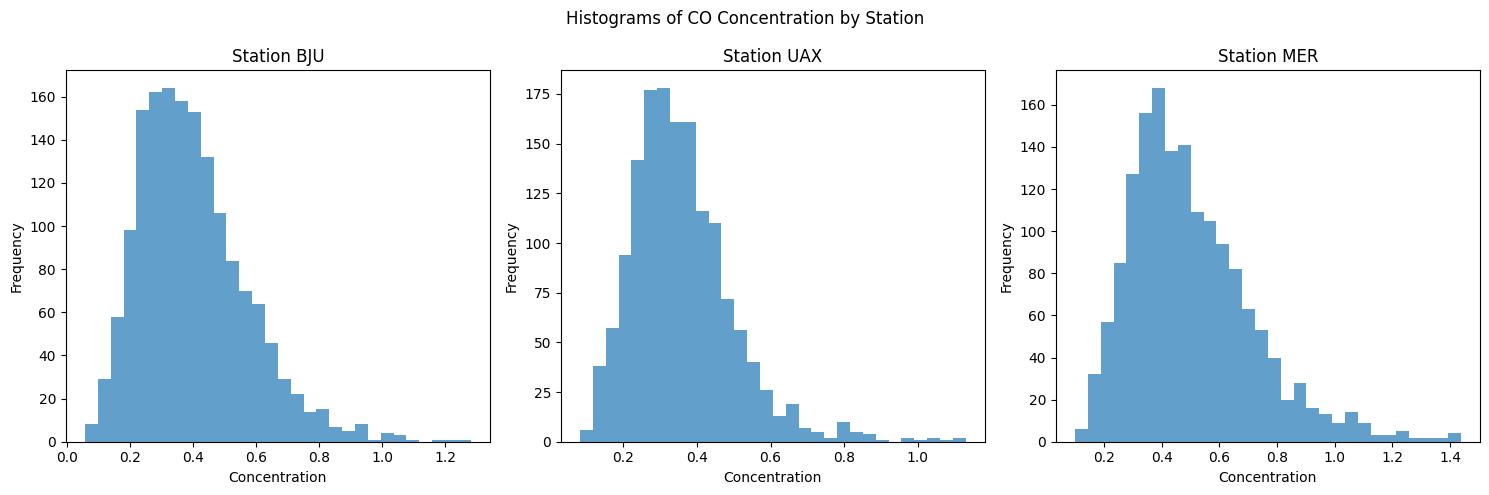

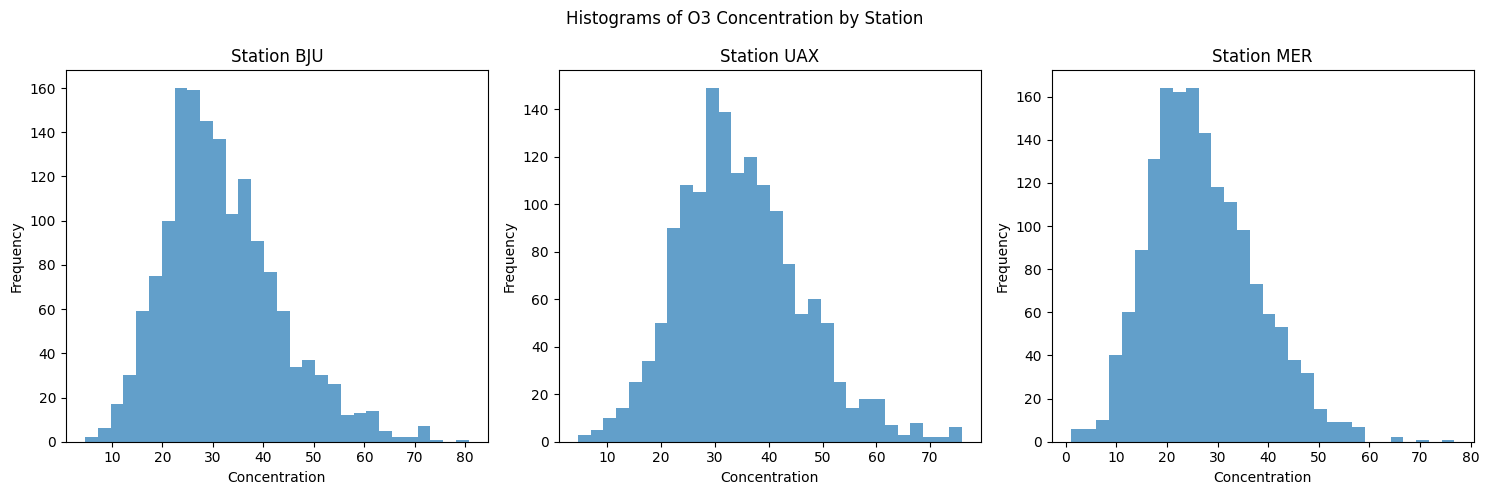

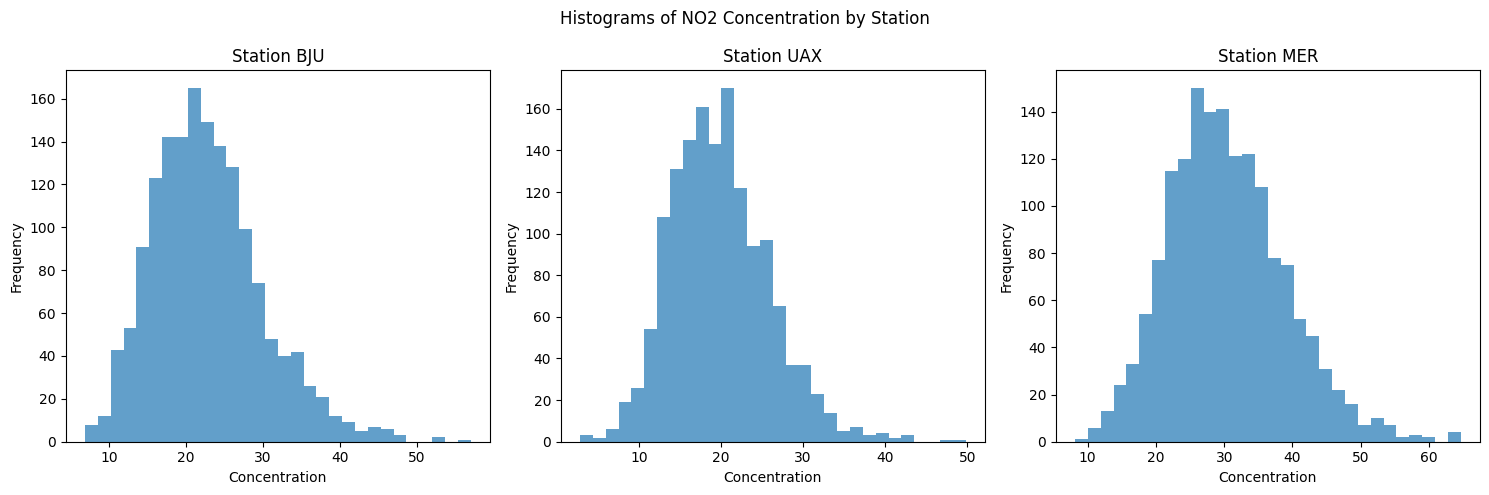

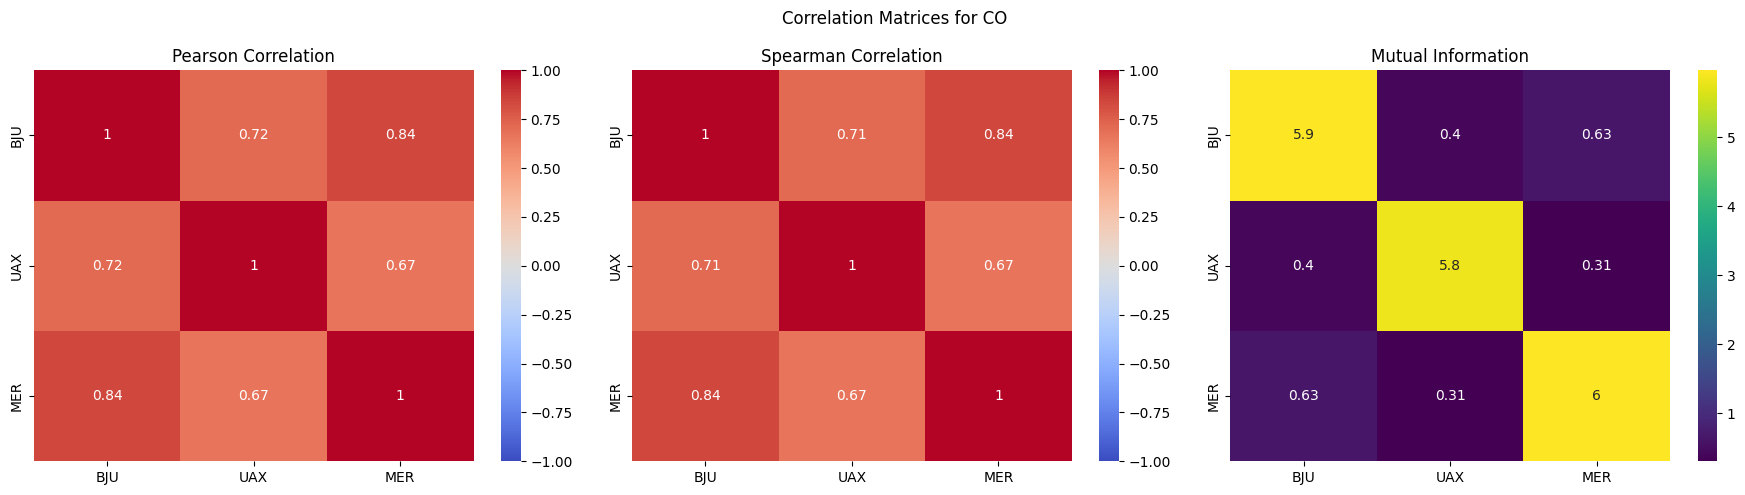

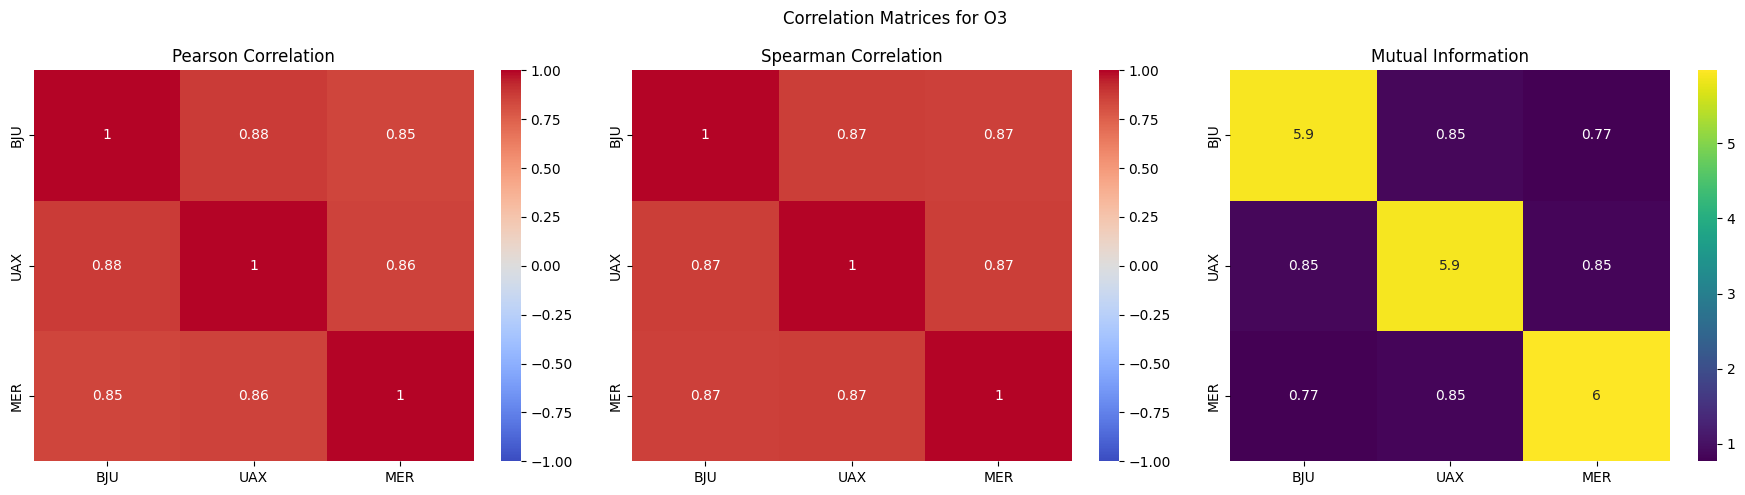

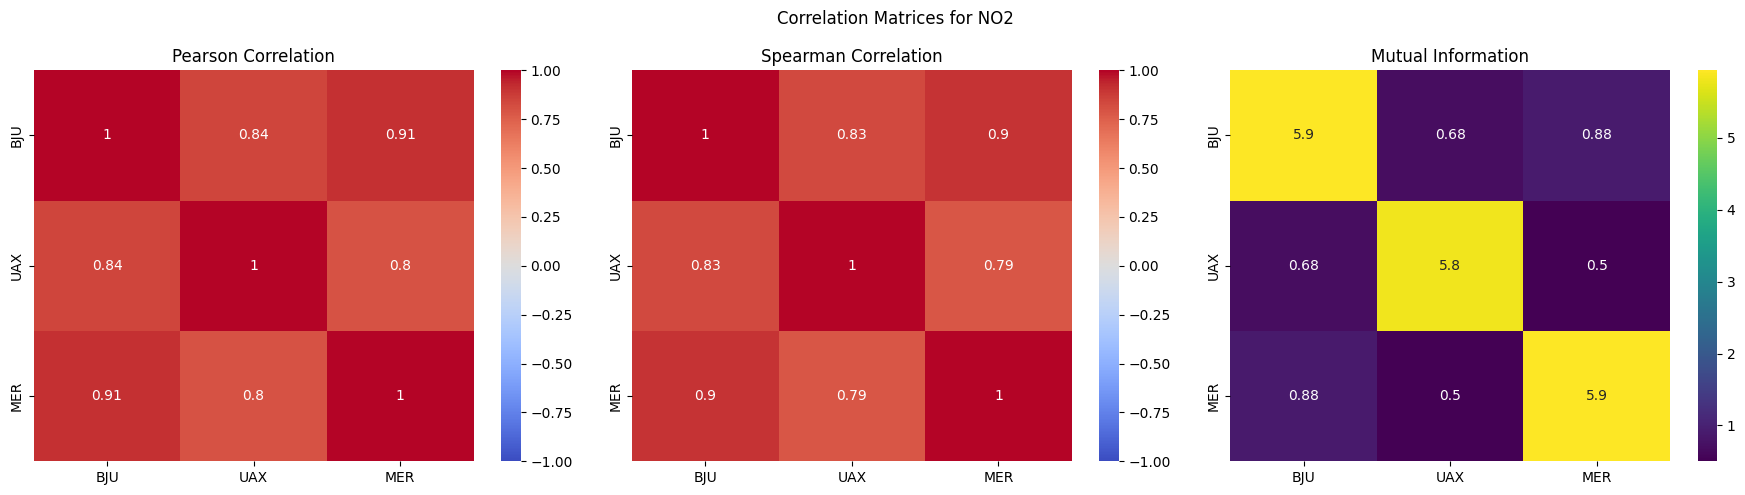

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob
from scipy.stats import pearsonr, spearmanr
from sklearn.feature_selection import mutual_info_regression

# Define contaminants and years
contaminants = ['CO', 'O3', 'NO2']
years = range(2020, 2025)  # 2020-2024
stations = ['BJU', 'UAX', 'MER']

# Dictionary to store processed data
data_by_contaminant = {contaminant: {} for contaminant in contaminants}

# Read all excel files and extract required data
for contaminant in contaminants:
    dfs = []
    for year in years:
        filename = f"{year}{contaminant}.xls"
        if os.path.exists(filename):
            print(f"Processing {filename}")
            try:
                # Read Excel file, adjust format as needed
                df = pd.read_excel(filename)
                
                # Filter only the required stations
                station_columns = [col for col in df.columns if col in stations]
                if not station_columns:
                    print(f"No required stations found in {filename}")
                    continue
                
                # Keep only date, time and station columns
                columns_to_keep = ['FECHA', 'HORA'] + station_columns
                df = df[columns_to_keep]
                
                # Convert -99 values to NaN (missing data)
                df = df.replace(-99, np.nan)
                
                # Add year information and append to list
                df['YEAR'] = year
                dfs.append(df)
            except Exception as e:
                print(f"Error processing {filename}: {e}")
    
    if dfs:
        # Combine all data for this contaminant
        combined_df = pd.concat(dfs, ignore_index=True)
        
        # Create datetime column
        combined_df['DATETIME'] = pd.to_datetime(combined_df['FECHA'], format='%d.%m.%Y', errors='coerce')
        combined_df['DATE'] = combined_df['DATETIME'].dt.date
        
        # Store in dictionary
        data_by_contaminant[contaminant] = combined_df
    else:
        print(f"No data found for {contaminant}")

# Calculate daily averages for each station and contaminant
daily_avg_by_contaminant = {}

for contaminant, df in data_by_contaminant.items():
    if not df.empty:
        # Group by date and calculate mean for each station
        daily_avg = df.groupby('DATE')[stations].mean()
        daily_avg_by_contaminant[contaminant] = daily_avg
        
        print(f"Daily averages for {contaminant}:")
        print(daily_avg.head())

# Create histograms of concentration for each contaminant by station
for contaminant, daily_avg in daily_avg_by_contaminant.items():
    fig, axes = plt.subplots(1, len(stations), figsize=(15, 5))
    fig.suptitle(f'Histograms of {contaminant} Concentration by Station')
    
    for i, station in enumerate(stations):
        if station in daily_avg.columns:
            axes[i].hist(daily_avg[station].dropna(), bins=30, alpha=0.7)
            axes[i].set_title(f'Station {station}')
            axes[i].set_xlabel('Concentration')
            axes[i].set_ylabel('Frequency')
    
    plt.tight_layout()
    plt.show()

# Compute correlation matrices for each contaminant
correlation_results = {}

for contaminant, daily_avg in daily_avg_by_contaminant.items():
    # Initialize correlation dictionaries
    pearson_corr = pd.DataFrame(index=stations, columns=stations)
    spearman_corr = pd.DataFrame(index=stations, columns=stations)
    mutual_info_corr = pd.DataFrame(index=stations, columns=stations)
    
    # Calculate correlations for each pair of stations
    for station1 in stations:
        for station2 in stations:
            if station1 in daily_avg.columns and station2 in daily_avg.columns:
                # Get data and replace -99 values with NaN (measurement errors)
                data1 = daily_avg[station1].replace(-99, np.nan)
                data2 = daily_avg[station2].replace(-99, np.nan)
                
                # Get data without NaN
                valid_mask = ~(data1.isna() | data2.isna())
                data1 = data1[valid_mask].values
                data2 = data2[valid_mask].values
                
                if len(data1) > 1:  # Need at least 2 points for correlation
                    # Pearson correlation
                    pearson, _ = pearsonr(data1, data2)
                    pearson_corr.loc[station1, station2] = pearson
                    
                    # Spearman correlation
                    spearman, _ = spearmanr(data1, data2)
                    spearman_corr.loc[station1, station2] = spearman
                    
                    # Mutual Information
                    mi = mutual_info_regression(data1.reshape(-1, 1), data2)
                    mutual_info_corr.loc[station1, station2] = mi[0]
    
    correlation_results[contaminant] = {
        'pearson': pearson_corr,
        'spearman': spearman_corr,
        'mutual_info': mutual_info_corr
    }
    
    # Before plotting, ensure all correlation matrices contain only numeric values
    pearson_corr = pearson_corr.astype(float)
    spearman_corr = spearman_corr.astype(float)
    mutual_info_corr = mutual_info_corr.astype(float)

    # Plot correlation matrices
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'Correlation Matrices for {contaminant}')
    
    sns.heatmap(pearson_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, ax=axes[0])
    axes[0].set_title('Pearson Correlation')
    
    sns.heatmap(spearman_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, ax=axes[1])
    axes[1].set_title('Spearman Correlation')
    
    sns.heatmap(mutual_info_corr, annot=True, cmap='viridis', ax=axes[2])
    axes[2].set_title('Mutual Information')
    
    plt.tight_layout()
    plt.show()


### 1. Como cambia el nivel de contaminacion durante el tiempo en cada estación?

Este análisis muestra cómo cambian los niveles de contaminación a lo largo del tiempo para cada estación y contaminante:

- Crea series temporales de promedios mensuales para cada contaminante (CO, O3, NO2)
- Visualiza la evolución de las concentraciones en las tres estaciones monitoreadas (BJU, UAX, MER)
- Permite identificar tendencias a largo plazo y comparar niveles entre estaciones

Resultados interesantes:
- Se observan patrones cíclicos en los niveles de O3, con picos que parecen ocurrir en ciertos periodos del año
- El CO muestra niveles relativamente estables con algunas fluctuaciones menores y picos los fines del año
- El NO2 presenta diferencias más marcadas entre estaciones, sugiriendo variabilidad espacial importante

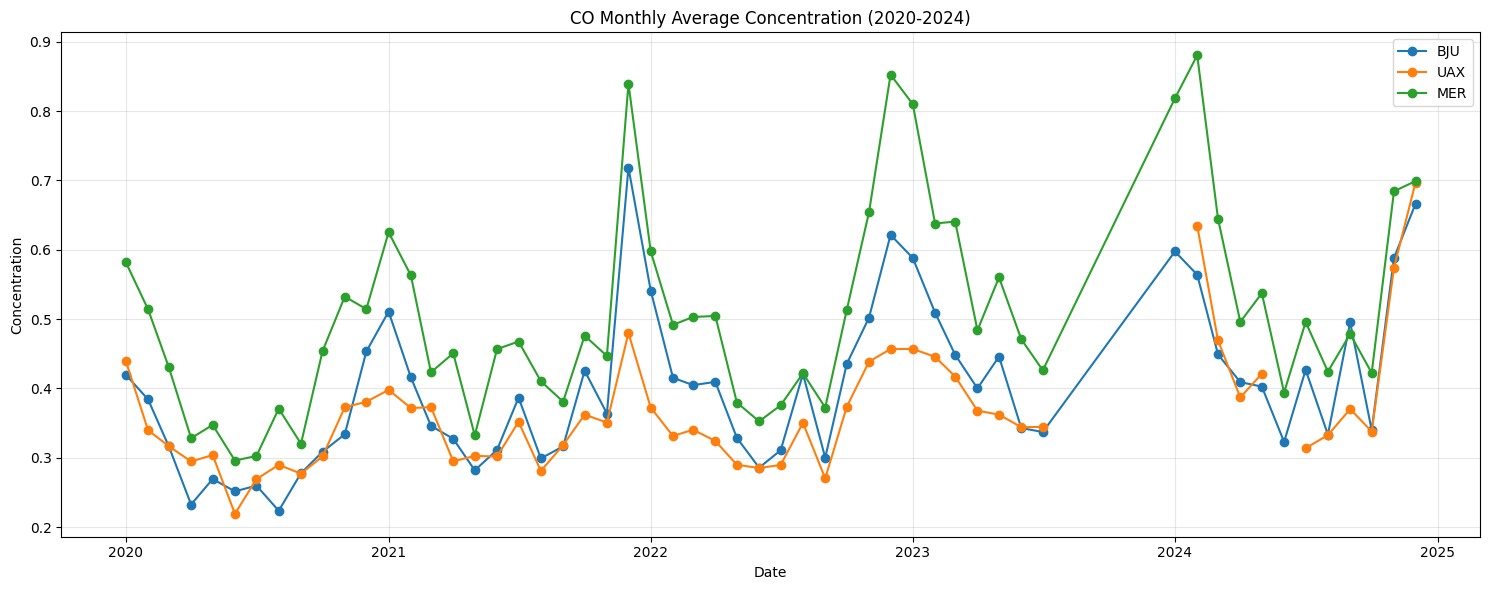

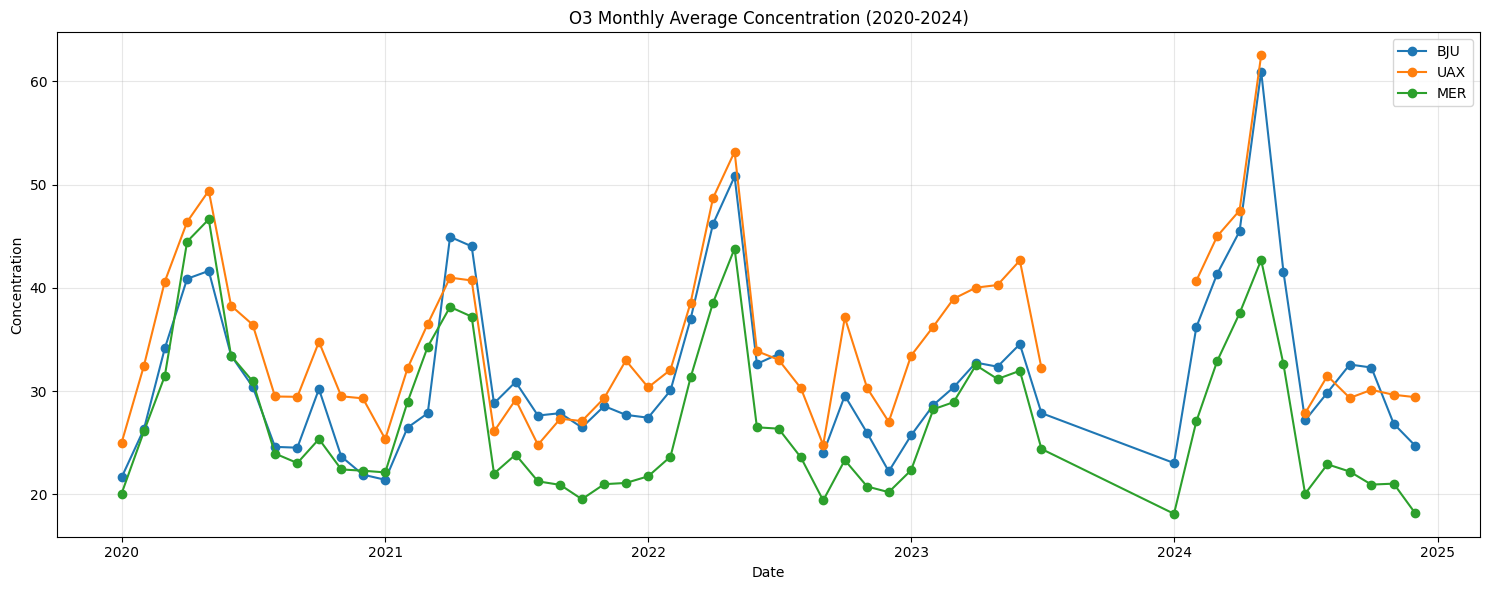

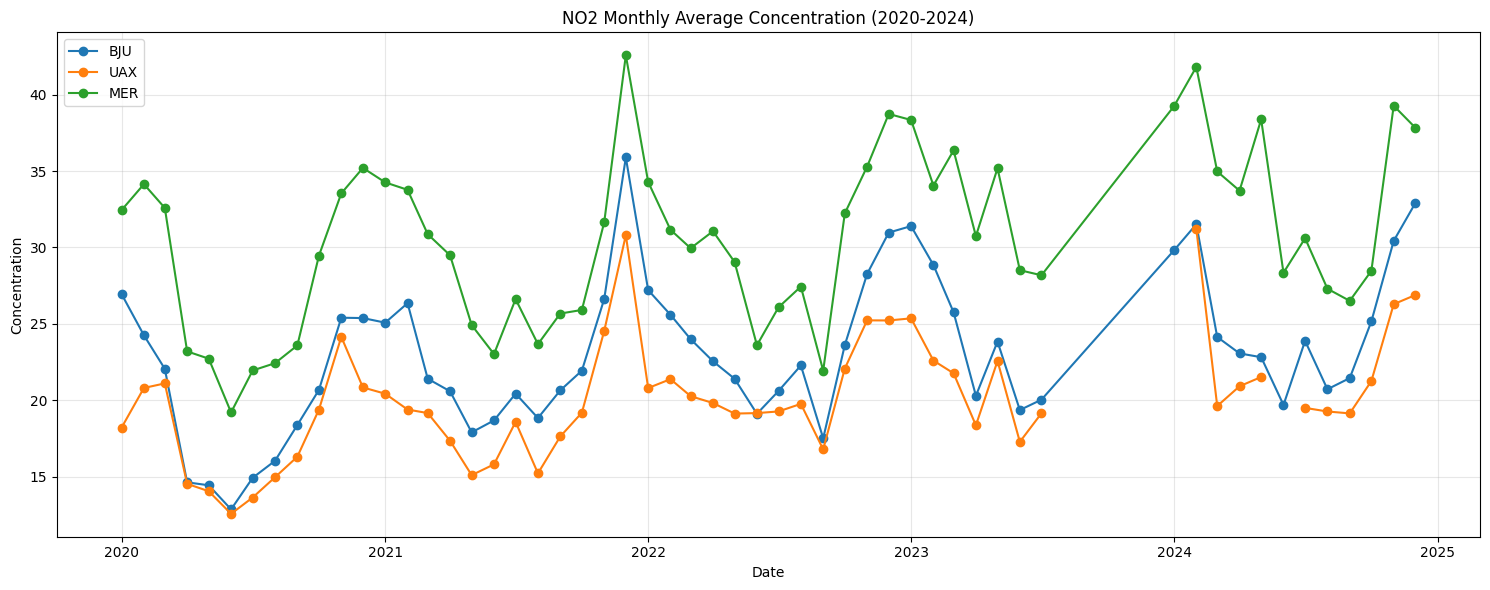

In [2]:
# Time series of contaminant levels with monthly averages
for contaminant, df in data_by_contaminant.items():
    if not df.empty:
        # Create a date index for proper time series with explicit index names
        monthly_avg = df.groupby([df['DATETIME'].dt.year, df['DATETIME'].dt.month])[stations].mean()
        monthly_avg.index.names = ['Year', 'Month']  # Give explicit names to prevent conflicts
        monthly_avg = monthly_avg.reset_index()
        
        # Create proper date column using the named columns
        monthly_avg['Date'] = pd.to_datetime(monthly_avg['Year'].astype(str) + '-' + 
                                          monthly_avg['Month'].astype(str) + '-01')
        
        plt.figure(figsize=(15, 6))
        for station in stations:
            if station in df.columns:
                plt.plot(monthly_avg['Date'], monthly_avg[station], marker='o', linestyle='-', label=station)
        
        plt.title(f'{contaminant} Monthly Average Concentration (2020-2024)')
        plt.xlabel('Date')
        plt.ylabel('Concentration')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

### 2. Hay patrones estacionales?

Este análisis examina si existen patrones estacionales en los niveles de contaminación:

- Utiliza diagramas de caja (boxplots) para visualizar la distribución de concentraciones por mes
- Agrupa los datos por mes (1-12) para cada estación y contaminante
- Permite identificar si ciertos meses presentan consistentemente mayores o menores niveles de contaminación

Observaciones clave:
- El ozono (O3) muestra un claro patrón estacional con niveles más altos durante los meses de primavera (marzo-mayo)
- El NO2 y CO muestra algunos patrones estacionales durante los meses de noviembre hasta febrero, posiblemente relacionados con patrones de tráfico o actividad industrial
- La variabilidad (tamaño de las cajas) también cambia según la temporada, sugiriendo que algunas épocas tienen concentraciones más estables que otras

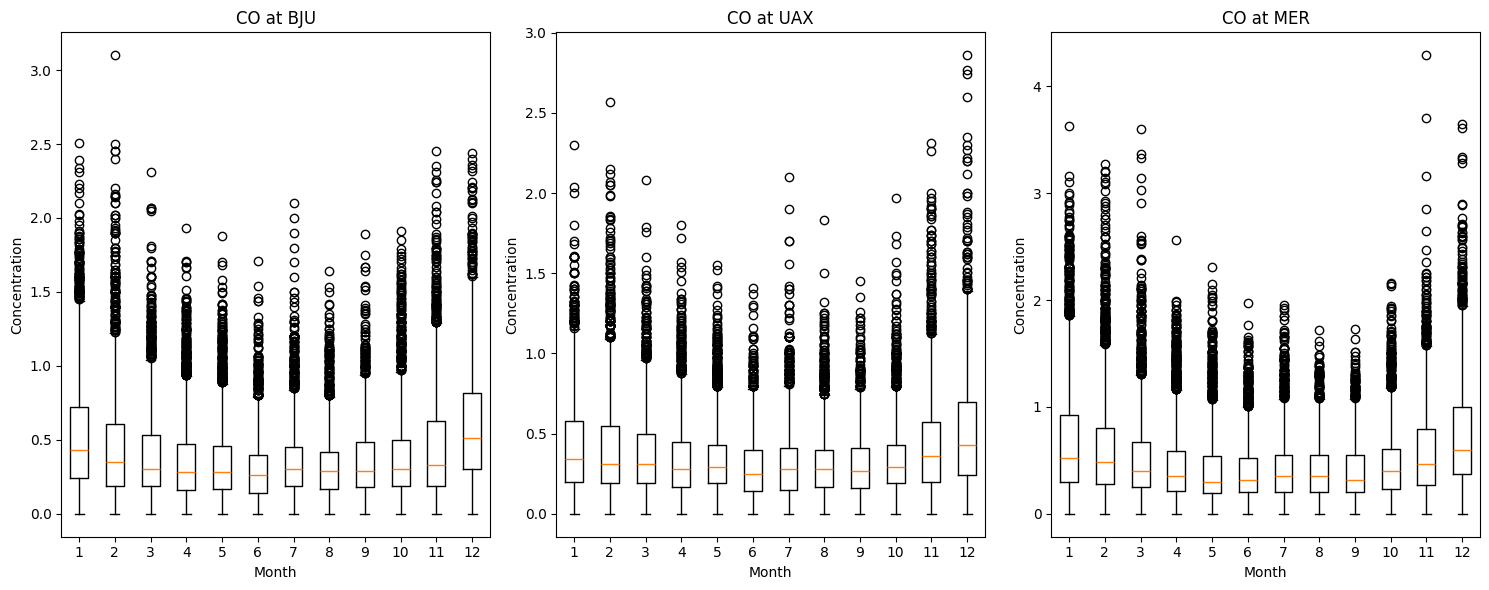

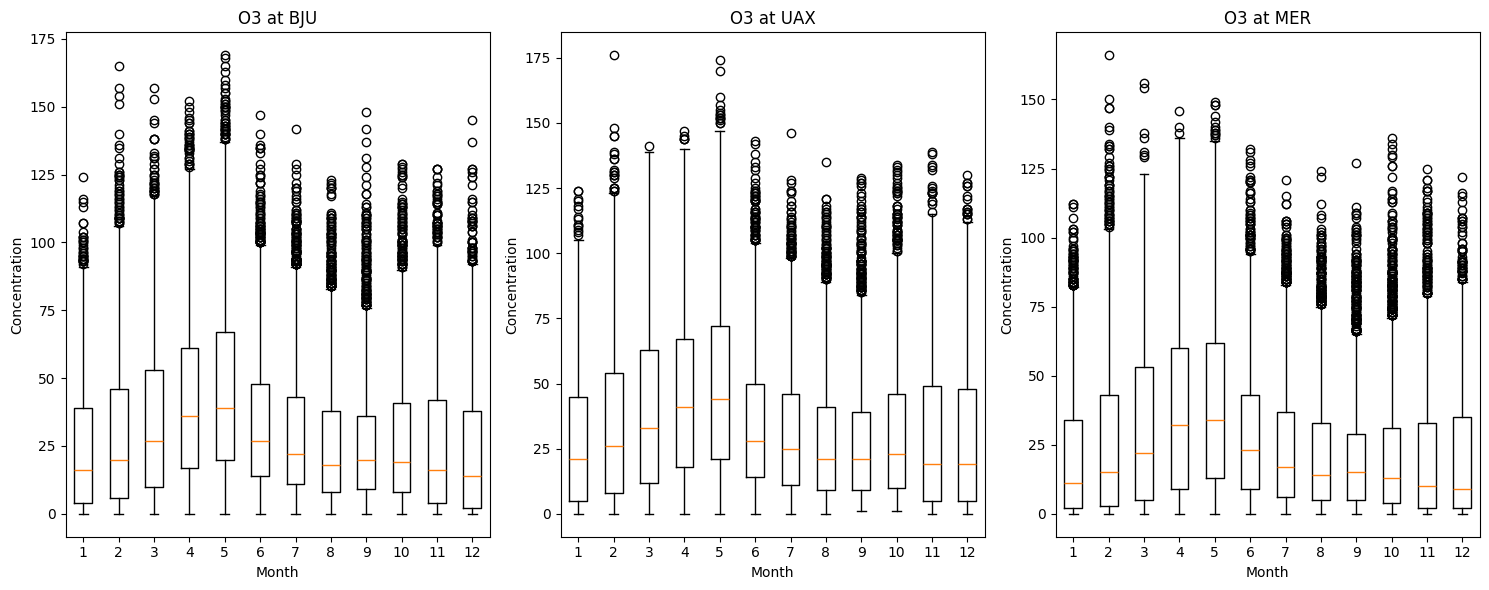

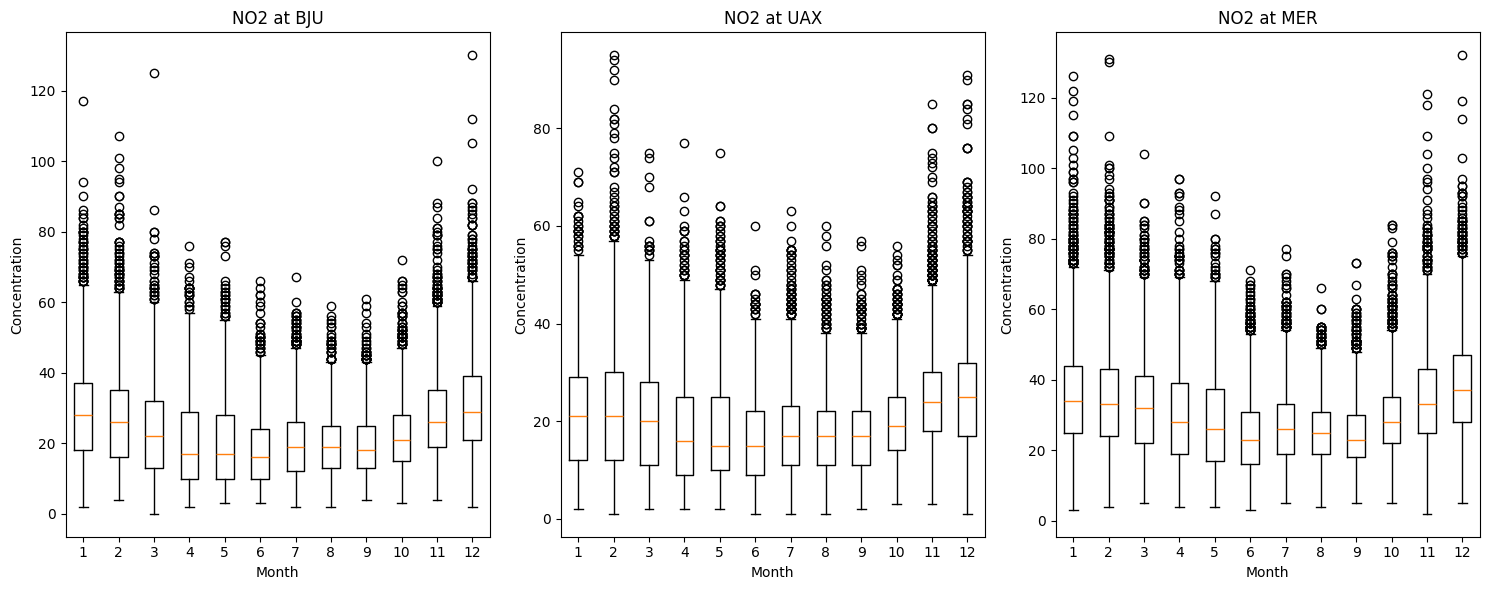

In [3]:
# Seasonal patterns (box plots by month)
for contaminant, df in data_by_contaminant.items():
    if not df.empty:
        # Add month column
        df['Month'] = df['DATETIME'].dt.month
        
        plt.figure(figsize=(15, 6))
        for i, station in enumerate(stations, 1):
            if station in df.columns:
                plt.subplot(1, len(stations), i)
                monthly_data = [df[df['Month'] == m][station].dropna() for m in range(1, 13)]
                plt.boxplot(monthly_data, labels=[f'{m}' for m in range(1, 13)])
                plt.title(f'{contaminant} at {station}')
                plt.xlabel('Month')
                plt.ylabel('Concentration')
        
        plt.tight_layout()
        plt.show()

### 3. Como se evoluciona la contaminacion promedia en cada estacion durante los 5 años analizados?

Este análisis compara los niveles promedio de contaminación año a año:

- Calcula el promedio anual de cada contaminante para cada estación
- Visualiza la evolución interanual mediante gráficos de barras
- Permite identificar tendencias a largo plazo y comparar entre los años 2020-2024

Resultados destacables:
- Se puede observar una tendencia general de empeoramiento de la calidad del aire
- Lo único que se mejoró durante los 4 años fueron los niveles de O3 en la estación de la Merced

<Figure size 1200x600 with 0 Axes>

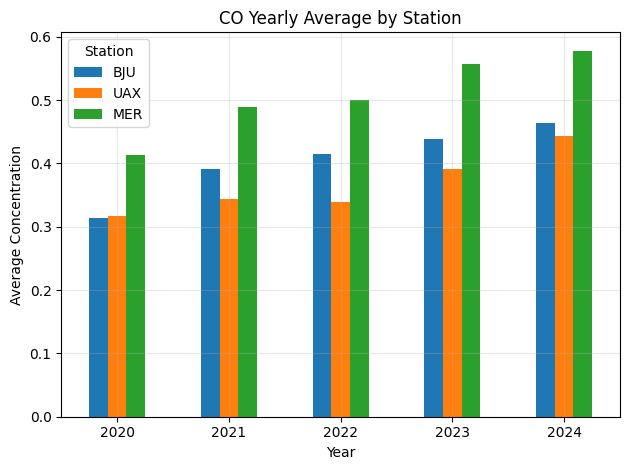

<Figure size 1200x600 with 0 Axes>

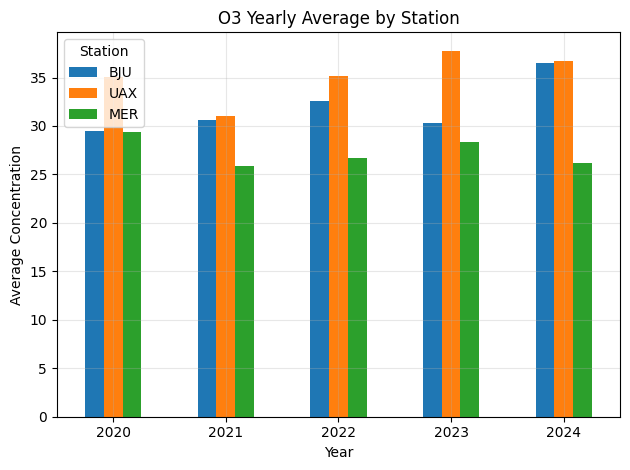

<Figure size 1200x600 with 0 Axes>

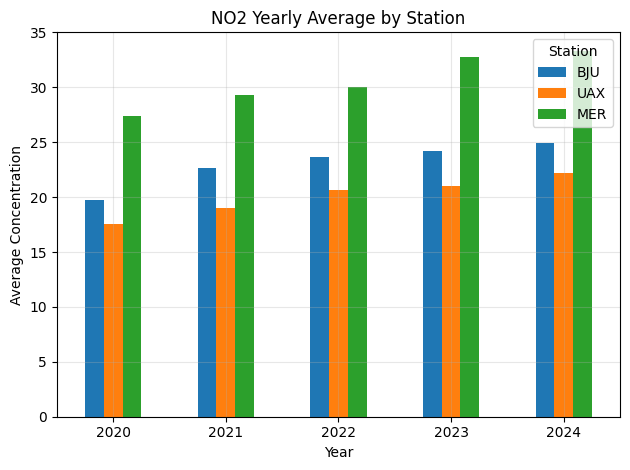

In [4]:
# Year-over-year comparison
for contaminant, df in data_by_contaminant.items():
    if not df.empty:
        yearly_avg = df.groupby('YEAR')[stations].mean()
        
        plt.figure(figsize=(12, 6))
        yearly_avg.plot(kind='bar')
        plt.title(f'{contaminant} Yearly Average by Station')
        plt.xlabel('Year')
        plt.ylabel('Average Concentration')
        plt.xticks(rotation=0)
        plt.legend(title='Station')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

### 4. Cuales son las horas con las contaminaciones más altas/bajas en cada estacion?

Este análisis examina cómo varían los niveles de contaminación a lo largo del día y de la semana:

- Gráficos de línea: muestran el promedio de concentración por hora del día para cada contaminante y estación
- Mapas de calor: visualizan la concentración por hora del día y día de la semana, identificando patrones temporal-semanales

Hallazgos importantes:
- Se observan claros patrones diarios en los contaminantes, especialmente:
  - El NO2 y CO muestra picos durante las horas pico de tráfico y la actividad urbana (mañana a partir de las 5 y tarde despues de las 6)
  - El O3 tiende a aumentar durante las horas de mayor radiación solar (mediodía-tarde)

- Los mapas de calor revelan diferencias entre días laborables y fines de semana:
  - Los niveles de contaminantes primarios (NO2, CO) suelen ser más bajos los fines de semana
  - El patrón temporal del O3 es similar entre días laborables y fines de semana
  
Estos patrones son consistentes con las fuentes esperadas de contaminación: tráfico vehicular (NO2, CO) y reacciones fotoquímicas (O3).

<Figure size 1200x600 with 0 Axes>

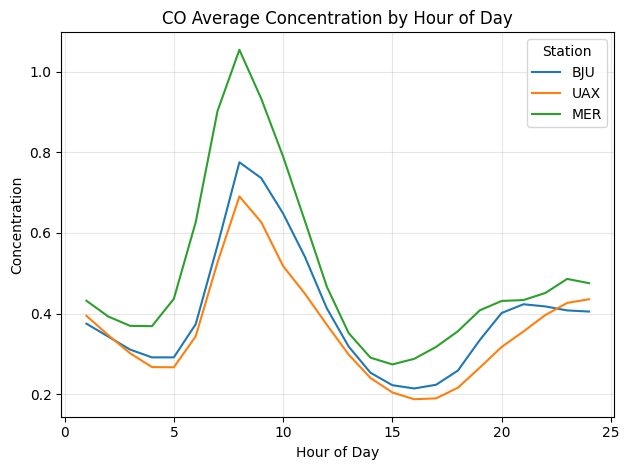

<Figure size 1200x600 with 0 Axes>

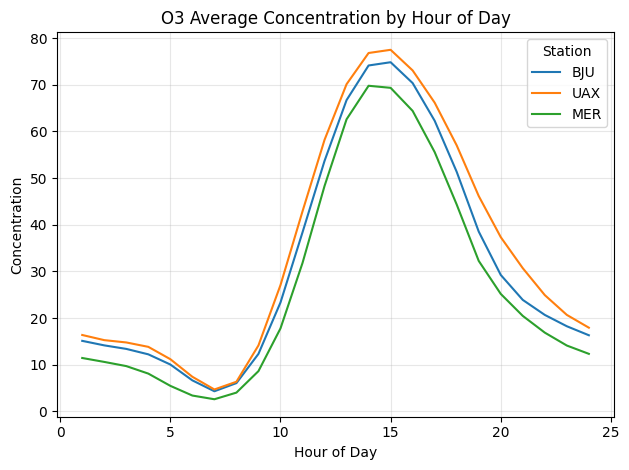

<Figure size 1200x600 with 0 Axes>

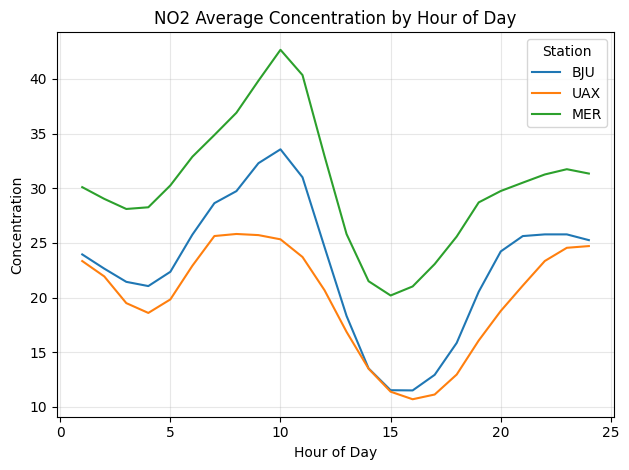

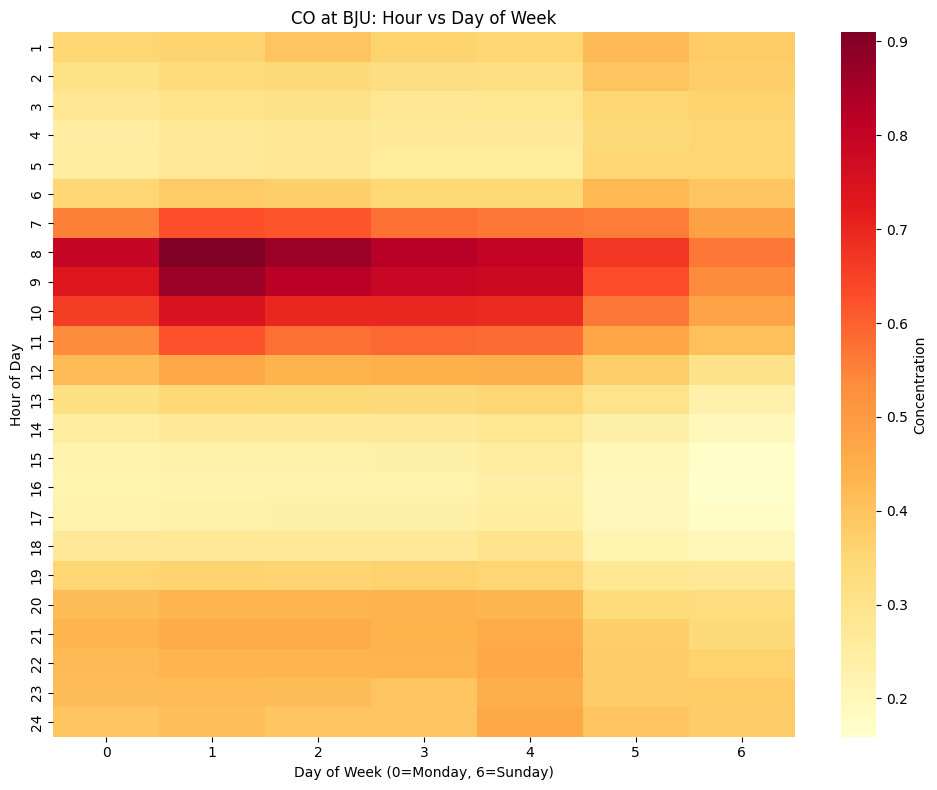

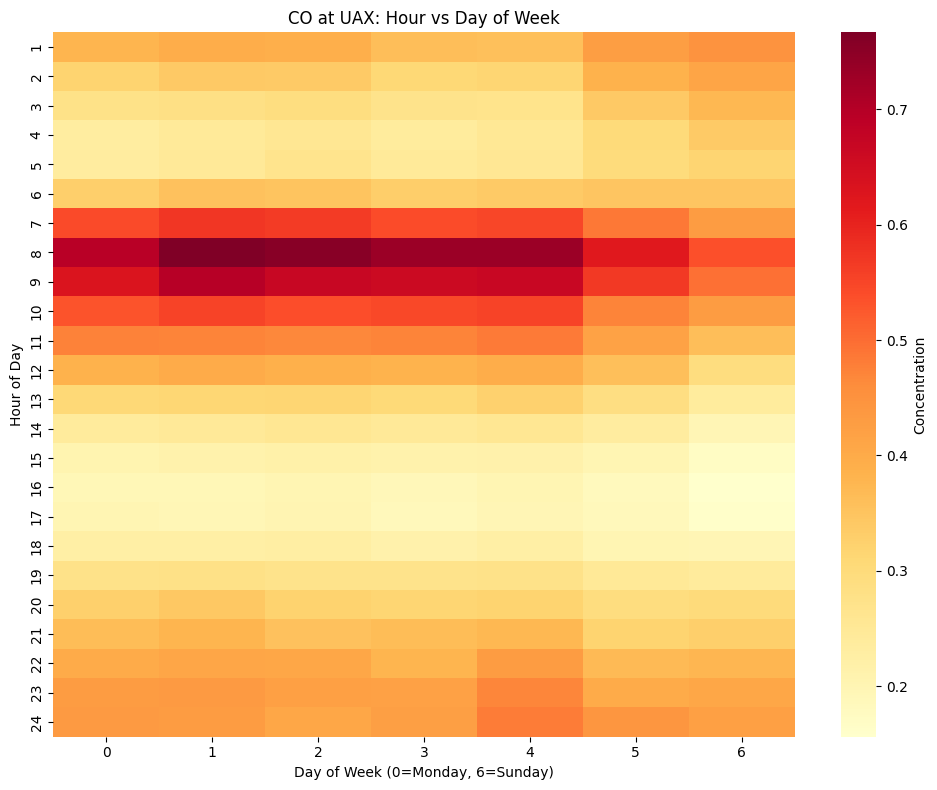

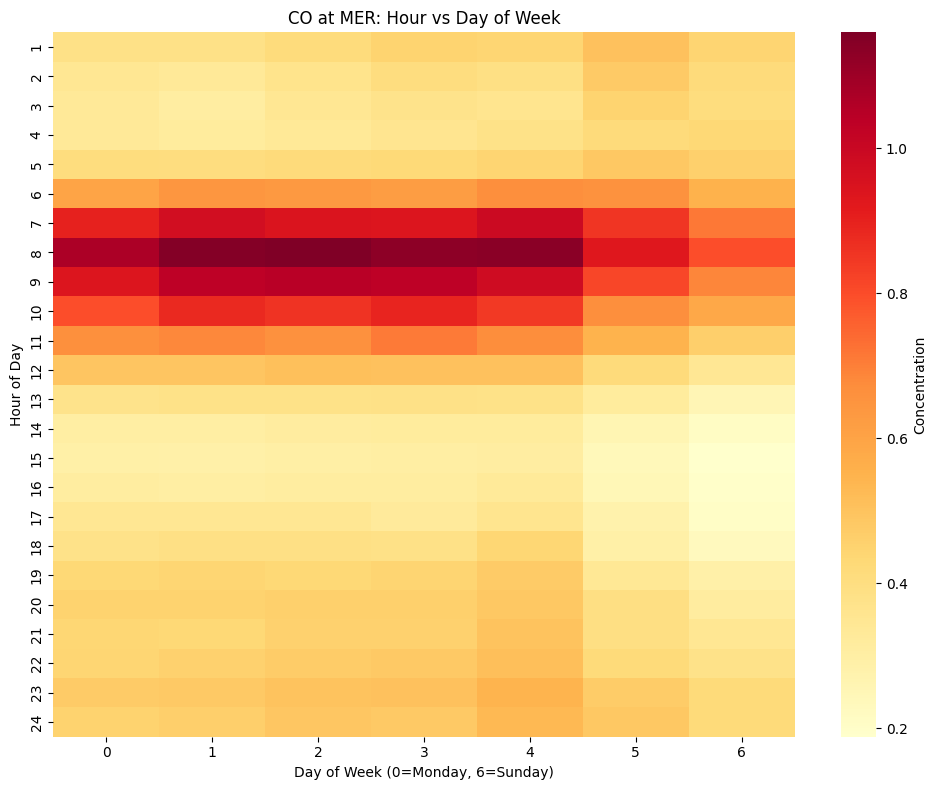

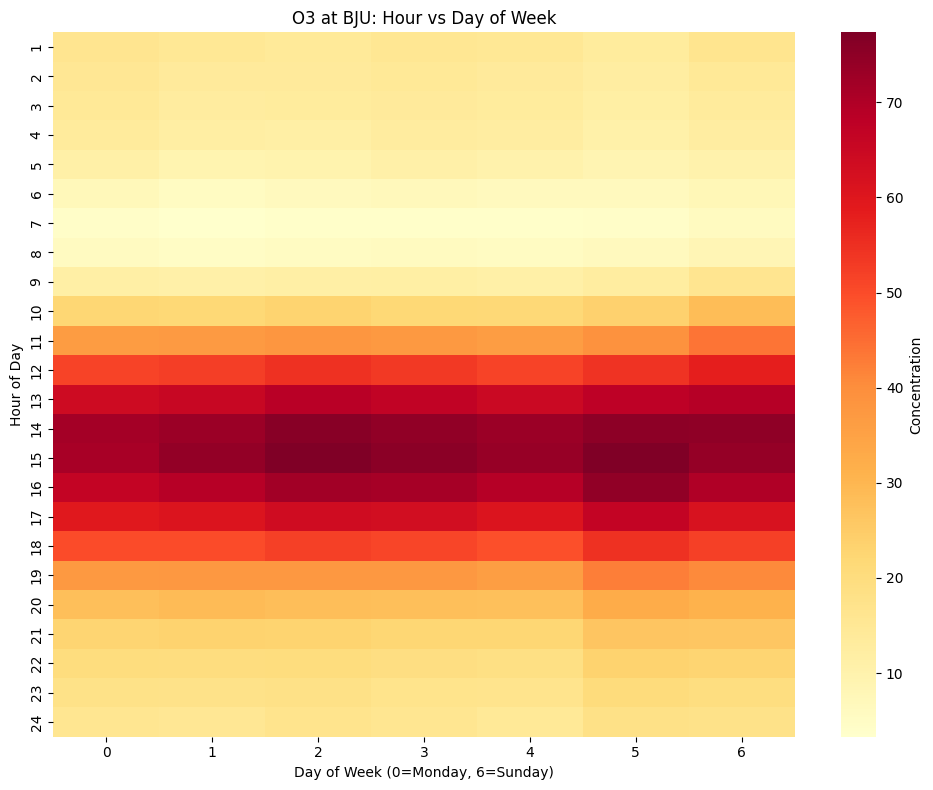

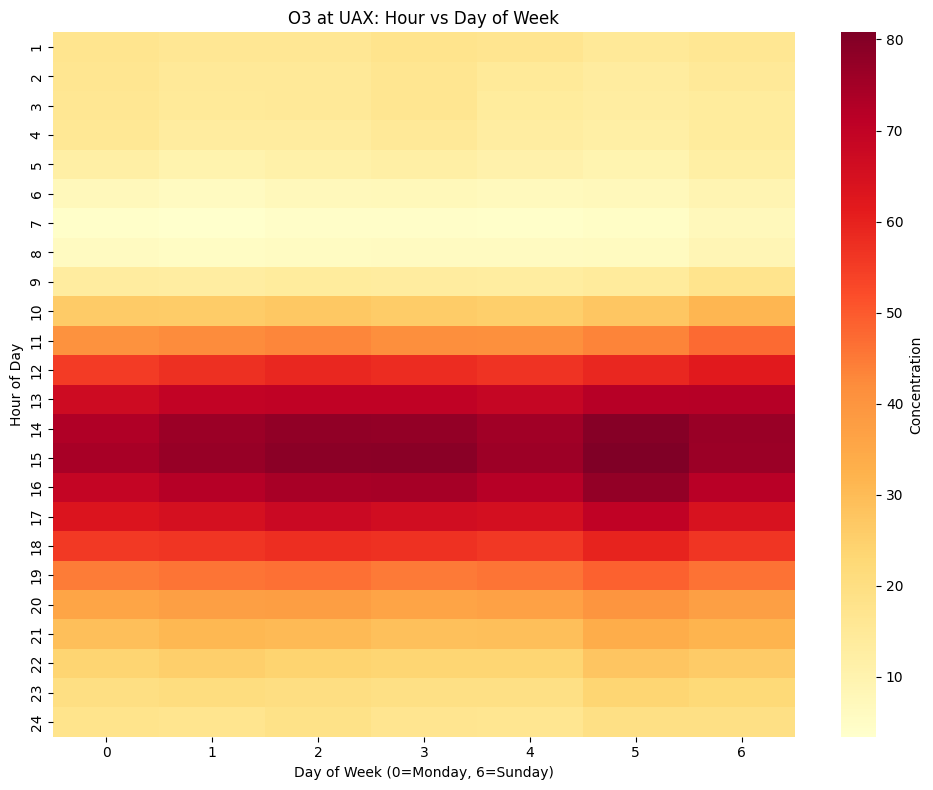

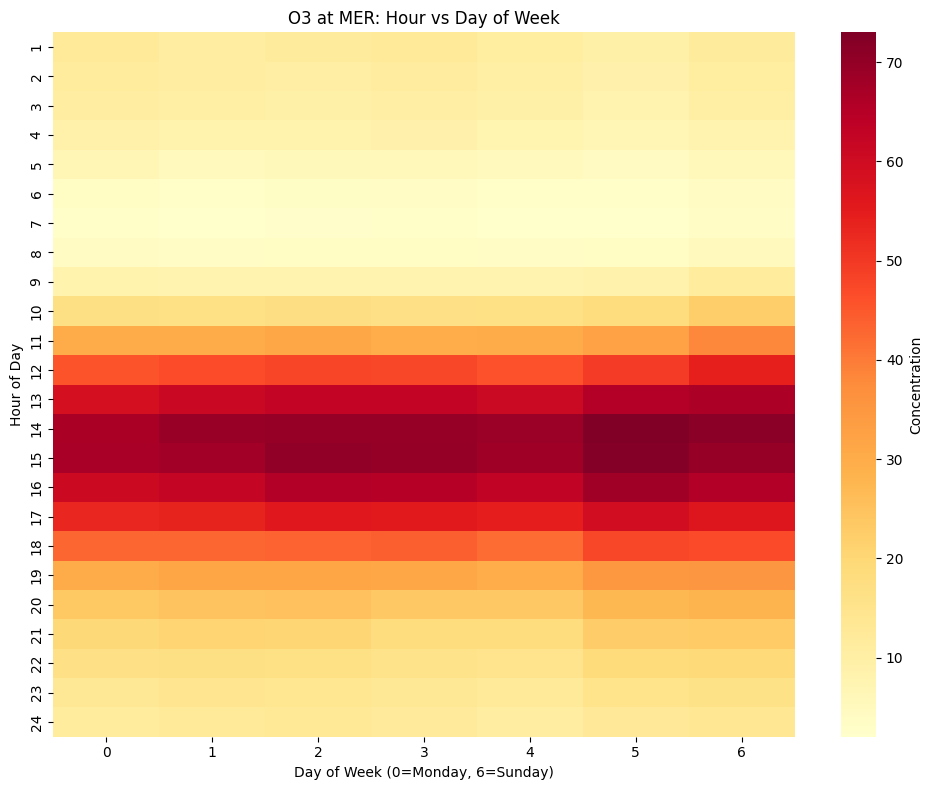

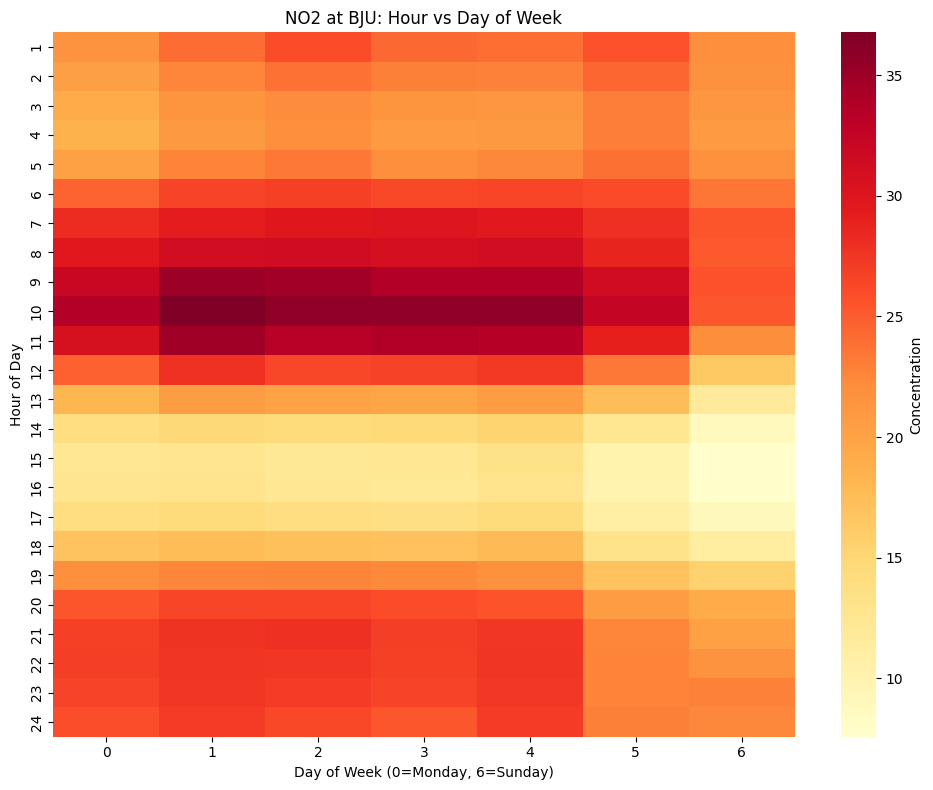

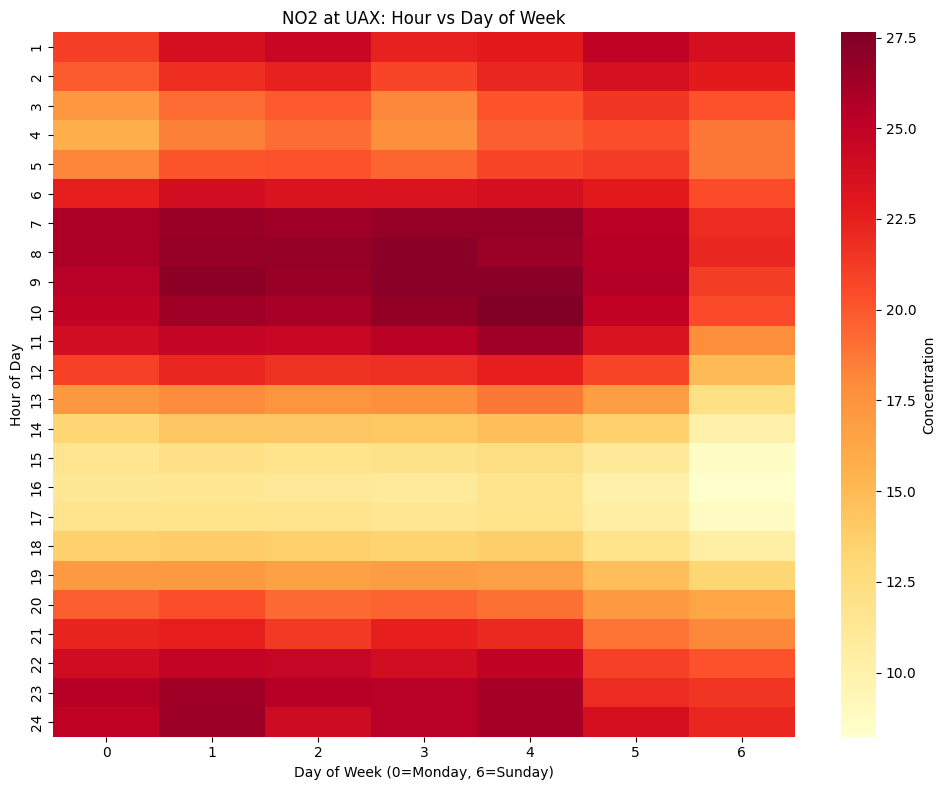

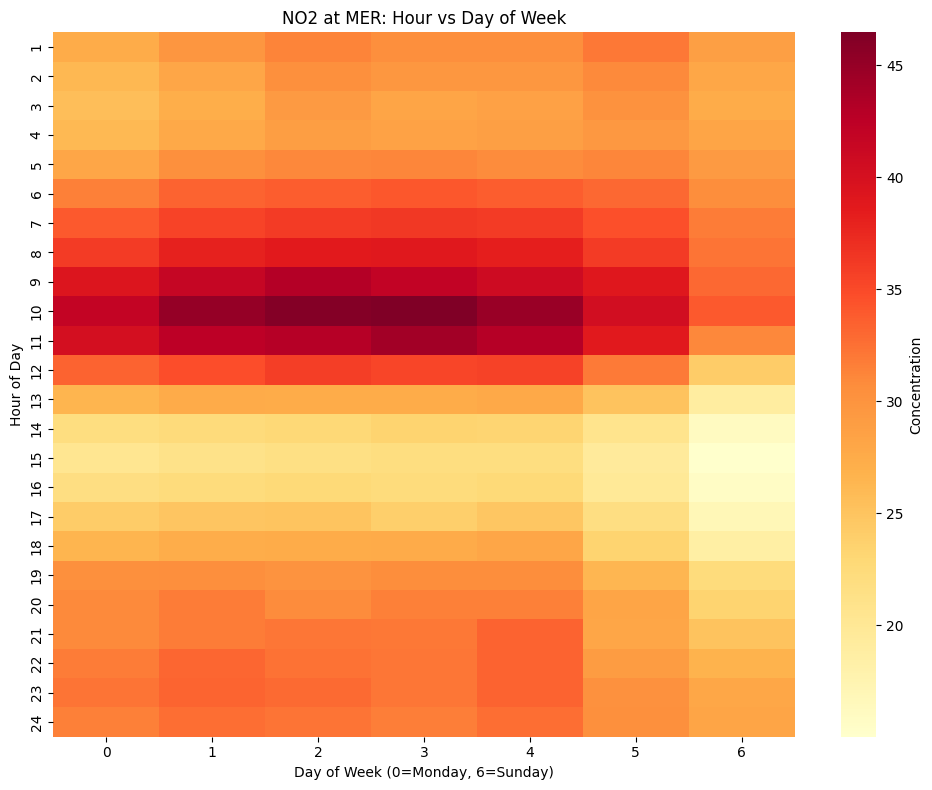

In [5]:
# Daily patterns (by hour of day)
for contaminant, df in data_by_contaminant.items():
    if not df.empty and 'HORA' in df.columns:
        hourly_avg = df.groupby('HORA')[stations].mean()
        
        plt.figure(figsize=(12, 6))
        hourly_avg.plot()
        plt.title(f'{contaminant} Average Concentration by Hour of Day')
        plt.xlabel('Hour of Day')
        plt.ylabel('Concentration')
        plt.grid(True, alpha=0.3)
        plt.legend(title='Station')
        plt.tight_layout()
        plt.show()

# Weekly patterns (heatmap)
for contaminant, df in data_by_contaminant.items():
    if not df.empty:
        # Add day of week
        df['DayOfWeek'] = df['DATETIME'].dt.dayofweek
        
        for station in stations:
            if station in df.columns:
                pivot = df.pivot_table(index='HORA', columns='DayOfWeek', values=station, aggfunc='mean')
                
                plt.figure(figsize=(10, 8))
                sns.heatmap(pivot, cmap='YlOrRd', annot=False, cbar_kws={'label': 'Concentration'})
                plt.title(f'{contaminant} at {station}: Hour vs Day of Week')
                plt.xlabel('Day of Week (0=Monday, 6=Sunday)')
                plt.ylabel('Hour of Day')
                plt.tight_layout()
                plt.show()

### 6. Cuales son las correlaciones de diferentes contaminantes en las 3 estaciones?

Matrices de correlación entre los contaminantes: se observa que existen correlaciones muy altes (>0.8) del mismo contaminante en varias estaciones, y correlaciones altas (0.7-0.8) entre NO2 y CO en diferentes estaciones. La correlación de O3 con los demás contaminantes es casi nula.

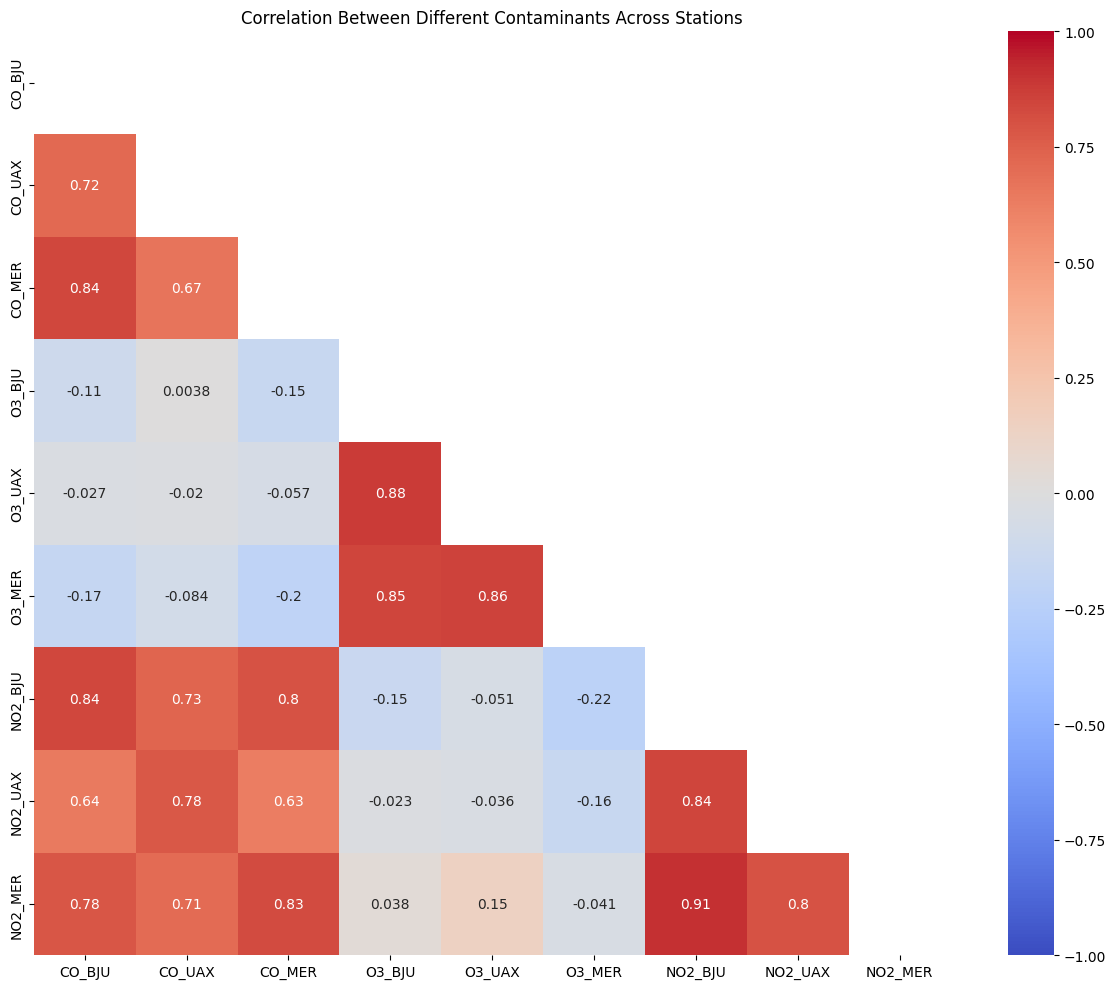

In [6]:
# Correlation between different contaminants
# Create a combined dataframe with all contaminants
combined_daily = pd.DataFrame()

for contaminant, daily_avg in daily_avg_by_contaminant.items():
    for station in stations:
        if station in daily_avg.columns:
            col_name = f"{contaminant}_{station}"
            combined_daily[col_name] = daily_avg[station]

# Calculate and plot correlation matrix
plt.figure(figsize=(12, 10))
corr_matrix = combined_daily.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, mask=mask, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Between Different Contaminants Across Stations')
plt.tight_layout()
plt.show()

Este análisis profundiza en las relaciones entre contaminantes en cada estación:

- Crea una matriz de gráficos de dispersión (pairplot) para cada estación
- Muestra las relaciones entre pares de contaminantes (CO-O3, CO-NO2, O3-NO2)
- Incluye histogramas de la distribución de cada contaminante en la diagonal

Conclusiones destacables:
- Se pueden observar relaciones lineales entre los contaminantes CO y NO2
- La relacion con O3 con otros contaminantes es no linear, pero se concentra en una región distinta


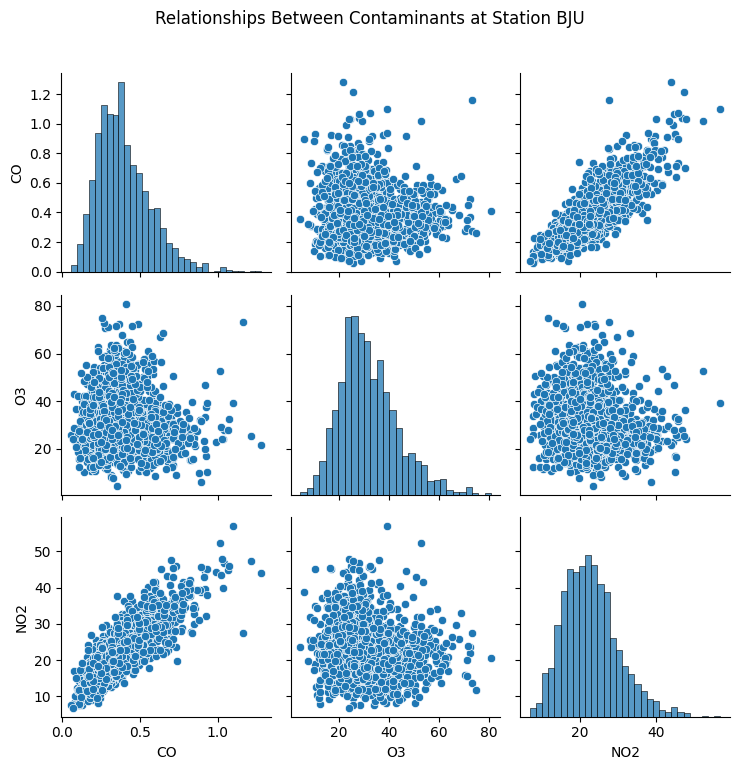

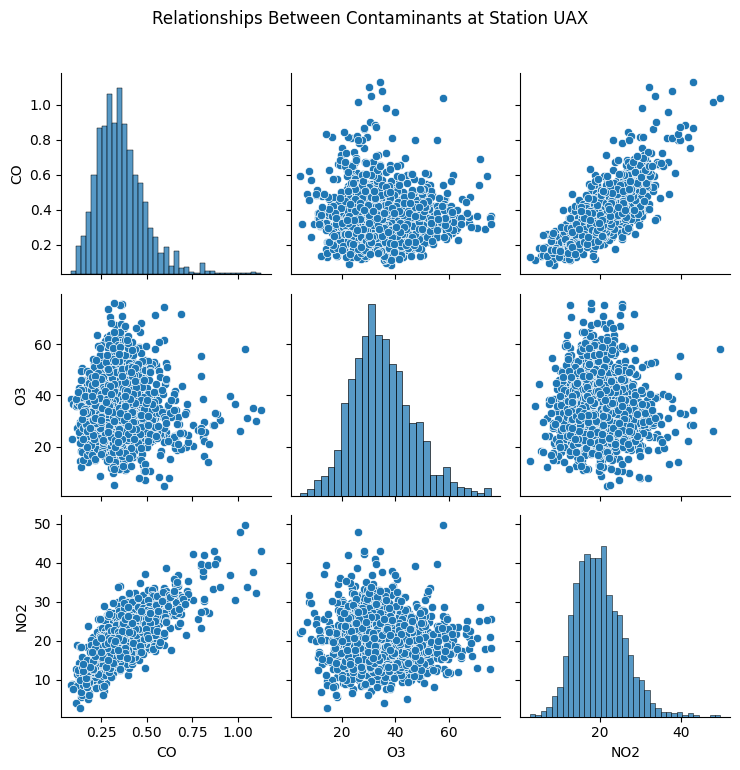

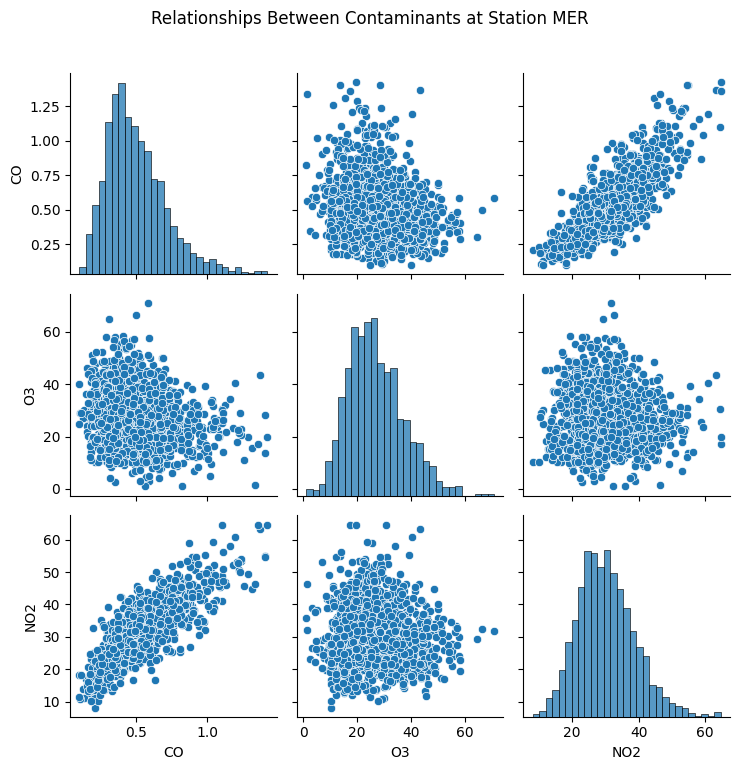

In [7]:
# Scatter plot matrix for different contaminants at the same station
for station in stations:
    station_data = pd.DataFrame()
    
    for contaminant, daily_avg in daily_avg_by_contaminant.items():
        if station in daily_avg.columns:
            station_data[contaminant] = daily_avg[station]
    
    if not station_data.empty and len(station_data.columns) > 1:
        sns.pairplot(station_data.dropna())
        plt.suptitle(f'Relationships Between Contaminants at Station {station}', y=1.02)
        plt.tight_layout()
        plt.show()